## FINAL CODE

## YOLO v12 + SAM

In [11]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 

from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask

In [12]:
# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolov12/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
csv_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_YOLO_v12_SAM_e_50.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

results_data = []

for img_name in os.listdir(data_folder):
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda") 
        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
        
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df.to_csv(csv_path, index=False)


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1102.jpg: 1024x1024 116 0s, 8.4ms
Speed: 7.0ms preprocess, 8.4ms inference, 82.1ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2582.jpg: 1024x1024 (no detections), 8.6ms
Speed: 3.0ms preprocess, 8.6ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/557.jpg: 1024x1024 79 0s, 7.8ms
Speed: 1.9ms preprocess, 7.8ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/787.jpg: 1024x1024 10 0s, 8.9ms
Speed: 2.6ms preprocess, 8.9ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2012.jpg: 1024x1024 24 0s, 8.3ms
Speed: 3.1ms 

In [13]:
len(os.listdir(data_folder))

576

In [14]:
metrics_df.head(5)

,pixel_iou,pixel_dice,pixel_accuracy,pixel_precision,pixel_recall,region_iou,region_dice,region_precision,region_recall,region_success_accuracy
0,0.885881,0.939488,0.999795,0.924654,0.954805,0.885881,0.939488,0.924654,0.954805,1.0
1,0.864611,0.927390,0.999807,0.907811,0.947832,0.864611,0.927390,0.907811,0.947832,1.0
2,0.899656,0.947178,0.999833,0.905366,0.993038,0.899656,0.947178,0.905366,0.993038,1.0
3,0.856960,0.922971,0.999786,0.904313,0.942416,0.856960,0.922971,0.904313,0.942416,1.0
4,0.817610,0.899654,0.999723,0.819156,0.997698,0.817610,0.899654,0.819156,0.997698,1.0


### This is for YOLO v12 + SAM

In [15]:
metrics_df.mean()

pixel_iou                  0.780119
pixel_dice                 0.863200
pixel_accuracy             0.998868
pixel_precision            0.855653
pixel_recall               0.904678
region_iou                 0.780119
region_dice                0.863200
region_precision           0.855653
region_recall              0.904678
region_success_accuracy    0.964625
dtype: float64

### lets test for single image as whole.


0: 1024x1024 42 0s, 8.0ms
Speed: 14.8ms preprocess, 8.0ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


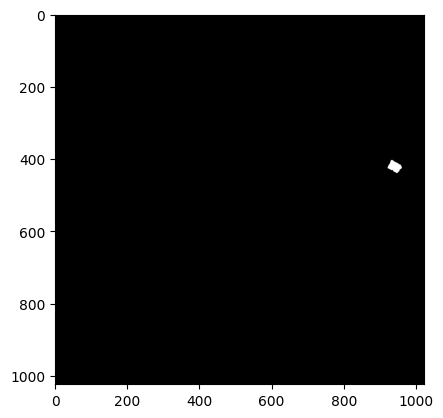

In [40]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt 



# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)


test_image = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1.jpg")
yolo_results = yolo_model.predict(test_image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(len(boxes))
sam_predictor.set_image(test_image)
masks, _, _ = sam_predictor.predict(box=boxes[3])
masks
plt.imshow(masks[0], cmap="gray")


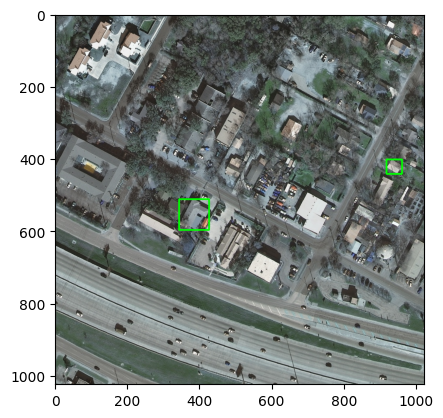

In [43]:
cv2.rectangle(test_image, (int(boxes[3][0]), int(boxes[3][1])), (int(boxes[3][2]), int(boxes[3][3])), (0, 255, 0), 3)
plt.imshow(test_image[:,:,::-1])

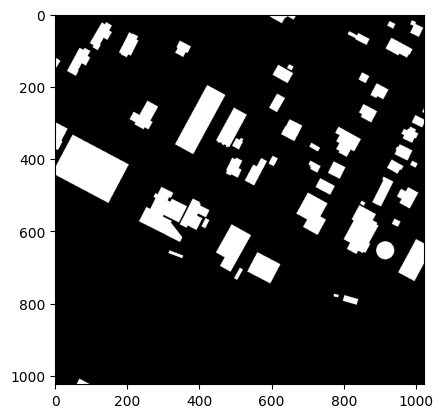

In [42]:
original_mask = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/1.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(original_mask, cmap="gray")

# try to test on indian image


0: 480x1024 2 0s, 8.4ms
Speed: 1.7ms preprocess, 8.4ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 1024)
2


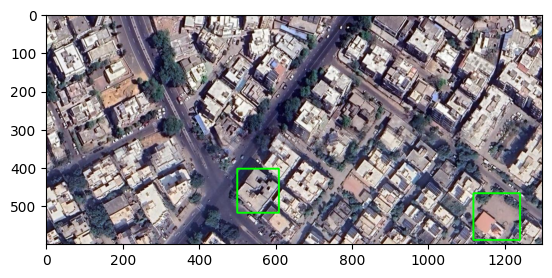

In [45]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt 



# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/yolo_v12/yolov12/runs/detect/train4/weights/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)


test_image = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_1.jpg")
yolo_results = yolo_model.predict(test_image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
print(len(boxes))
sam_predictor.set_image(test_image)

demo = test_image.copy()
for i in boxes:
    cv2.rectangle(demo, (int(i[0]), int(i[1])), (int(i[2]), int(i[3])), (0, 255, 0), 3)

plt.imshow(demo[:,:,::-1])

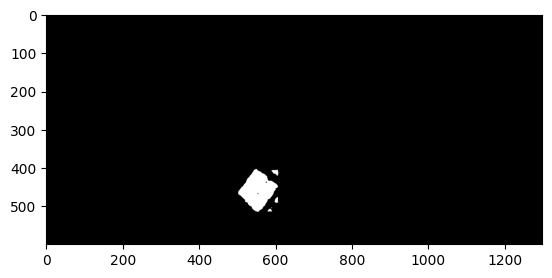

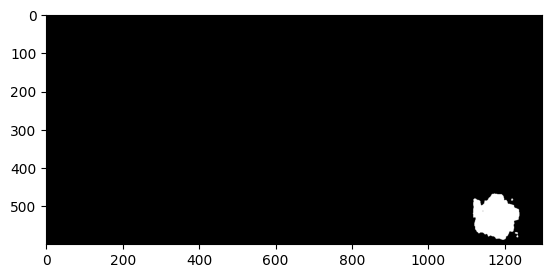

In [46]:
for i in boxes:
    masks, _, _ = sam_predictor.predict(box=i)
    plt.imshow(masks[0], cmap="gray")
    plt.show()

# YOLO v11 + SAM

In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask

In [3]:
# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/YOLOV_11/best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
csv_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_1_YOLOv11_SAM.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

results_data = []

for img_name in os.listdir(data_folder):
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda") 
        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
        
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df.to_csv(csv_path, index=False)


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1102.jpg: 1024x1024 153 0s, 5.5ms
Speed: 2.4ms preprocess, 5.5ms inference, 8.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2582.jpg: 1024x1024 1 0, 6.9ms
Speed: 5.1ms preprocess, 6.9ms inference, 5.0ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/557.jpg: 1024x1024 100 0s, 5.5ms
Speed: 2.4ms preprocess, 5.5ms inference, 3.5ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/787.jpg: 1024x1024 12 0s, 6.1ms
Speed: 2.7ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2012.jpg: 1024x1024 23 0s, 7.6ms
Speed: 2.4ms preprocess, 

In [2]:
import os

In [3]:
len(os.listdir("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"))

576

In [4]:
len(os.listdir("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"))

576

In [5]:
len(os.listdir("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images"))

2304

In [6]:
len(os.listdir("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/masks"))

2304

In [9]:
import pandas as pd
metrics_df = pd.read_csv("/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_1_YOLOv11_SAM.csv")
metrics_df.head(5)
metrics_df.mean()

pixel_iou                  0.779427
pixel_dice                 0.861659
pixel_accuracy             0.998940
pixel_precision            0.853415
pixel_recall               0.906468
region_iou                 0.779427
region_dice                0.861659
region_precision           0.853415
region_recall              0.906468
region_success_accuracy    0.961550
dtype: float64

# YOLO v10

In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask

In [2]:
# Load YOLO model 
yolo_model = YOLO("/home/selc-a4-sr2/v_10best.pt")

# Load SAM model 
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

data_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images"
mask_folder = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks"
csv_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_1_YOLOv10_SAM.csv"
os.makedirs(os.path.dirname(csv_path), exist_ok=True)

results_data = []

for img_name in os.listdir(data_folder):
    
    img_path = os.path.join(data_folder, img_name)
    image = cv2.imread(img_path)
    
    yolo_results = yolo_model.predict(img_path, conf=0.5, device="cuda")
    boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
    
    mask_path = os.path.join(mask_folder, img_name)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.from_numpy(gt_mask).to("cuda")  # Convert to torch tensor on GPU
    
    sam_predictor.set_image(image)
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        isolated_mask = generate_isolated_mask(gt_mask, [x1, y1, x2, y2])
        
        masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
            
        pred_mask = masks[0]
        pred_mask = torch.from_numpy(masks[0]).to("cuda") 
        metrics = compute_metrics(pred_mask, isolated_mask)

        results_data.append(metrics)
        
metrics_df = pd.DataFrame(results_data, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall", "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])
metrics_df.to_csv(csv_path, index=False)


image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/1102.jpg: 640x640 96 0s, 6.3ms
Speed: 1.9ms preprocess, 6.3ms inference, 12.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2582.jpg: 640x640 (no detections), 6.5ms
Speed: 1.6ms preprocess, 6.5ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/557.jpg: 640x640 71 0s, 5.7ms
Speed: 1.5ms preprocess, 5.7ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/787.jpg: 640x640 9 0s, 6.6ms
Speed: 1.6ms preprocess, 6.6ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/2012.jpg: 640x640 20 0s, 6.5ms
Speed: 1.7ms preprocess, 6.5ms in

In [3]:
import pandas as pd
metrics_df = pd.read_csv("/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection/Validation_results/validation_results_1_YOLOv10_SAM.csv")
metrics_df.head(5)
metrics_df.mean()

pixel_iou                  0.779056
pixel_dice                 0.864345
pixel_accuracy             0.998675
pixel_precision            0.856276
pixel_recall               0.902692
region_iou                 0.779056
region_dice                0.864345
region_precision           0.856276
region_recall              0.902692
region_success_accuracy    0.970121
dtype: float64